### The point of this notebook is to be a small demonstration of the neural network and how the predicted melt rates change when input variables are changed 

## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [2]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_y1985.1y_gridT.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979.nc'

# NEMO full grid coords
filepath_domain_cfg = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Set the filepaths 

# And the location of the output files 
folder_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 
filepath_nn_output = folder_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'



In [3]:
# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = False
nemo_version = '5'

# The target grid mask 
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
# The target grid geometry
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# Create functions which will apply the NN to each year of T and S output

In [4]:
# A function to load so and thetao for each input file
def func_data_load(filepath_nemo_output):
    gridT_varofint = xr.open_dataset(filepath_nemo_output)
    #print('You have loaded T and S:', filepath_nemo_output)
    # And cut out variables which are not needed
    gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop_vars('time_counter').drop_vars('time_centered')
    # Crop out most of the world and just save Antarctica 
    # Specify the coordinates needed
    min_lat = -52.2
    y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
    #print('Cropped to Antarctica only')
    # Take this slice 
    #gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))[['thetao','so', 'area', 'bathy', 'isf_draft']]
    gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))
    gridT2 = normalise_variable_names(gridT2)
    gridT2 = gridT2[['thetao', 'so']]#, 'area']]
    # Close the original dataset
    so = gridT2.so
    thetao = gridT2.thetao
    #print('Minimum salinity is:', np.nanmin(so.values))
    #print('Maximum salinity is:', np.nanmax(so.values))
    #ax.scatter(i, np.nanmin(so.values), c = 'red')
    #ax.scatter(i, np.nanmax(so.values), c = 'green')
    return so, thetao

In [5]:
# Load in the mask for the ocean region 
bmach_masks = xr.open_dataset(filepath_eORCA1_bmach_masks)
mask_nocavs = bmach_masks.mask_nocavs.values
bmach_masks.close()

# Load in the mask and geometry 
masks, basins_merged, geoms = load_geom_files(filepath_geomvars, 
                                              filepath_mask, 
                                              join_ice_shelves = join_ice_shelves)
# Rename the dimensions of basins merged to be x and y 
if 'y_grid_T' in basins_merged.dims:
    basins_merged = basins_merged.rename({"y_grid_T": "y", "x_grid_T": "x"}).astype(int)
# Load in the coordinates for the grid 
coords = load_gridcoords(filepath_nemo_output)
# The basins mask for the NEMO 025 grid  
basins_NEMO = masks.basins_NEMO.values
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
basin_nos = np.arange(1,156, dtype = 'float32')
basin_nos = np.unique(basins_NEMO)

# Regions where it is acceptable to extract ocean profiles 
iy, ix = np.where((mask_nocavs == 1))
# coordinates of those cells
lat_ocean = coords.nav_lat.values[iy, ix]
lon_ocean = coords.nav_lon.values[iy, ix]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_ocean, y_ocean = transformer.transform(lat_ocean, lon_ocean)
# Stack to prepare for the KDTree
ocean_points = np.column_stack((x_ocean, y_ocean))
# Create KDTree
tree = cKDTree(ocean_points)

You have loaded: /bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc
You have loaded coordinates: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only


In [6]:
def calculate_TS_profiles(filepath_nemo_output):
    gridT2 = load_TSmelt_normal(filepath_nemo_output);

    # For each basin in basin_nos, create a mask of the ocean profiles to extract 
    profiles_all = []
    i_no_value = []
    basins_all_temp = np.zeros_like(mask_nocavs)
    for kk in range(len(basin_nos)):
        i = basin_nos[kk]
        mask_basin_cavs = (basins_NEMO == i) & (masks.closed_cavities == 1)
        # Extract these points 
        idx = np.where(mask_basin_cavs == 1)
        lat_cavs = masks.lat.values[idx]
        lon_cavs = masks.lon.values[idx]
        # Transform to x and y
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)
        # Stack cavity points to query KDTree
        cav_points = np.column_stack((x_cavs, y_cavs))
        dist, idx = tree.query(cav_points)
        # Same dimensions as the mask of the not cavities
        ocean_edge_basin = np.zeros_like(mask_nocavs)
        # And fill the cells found with the kd-tree
        # Should allow cells which are adjacent or as close to adjacent as possible
        if len(idx) == 1:
            for k in range(len(idx)):
                ocean_edge_basin[iy[idx[k]], ix[idx[k]]] = 1
        elif len(idx) != 0:
            idxn = np.unique(idx[dist < np.min(dist[dist != np.min(dist)]) * 2])
            for k in range(len(idxn)):
                ocean_edge_basin[iy[idxn[k]], ix[idxn[k]]] = 1
        else:
            # Calculate which basins don't have profiles
            i_no_value.append(int(i))
        ### This is only needed if you want to look at which ocean cells will recieve melt from many basins   
        basins_all_temp = basins_all_temp + ocean_edge_basin
        
        # Use the mask to extract the relevant profiles 
        masked_depth = gridT2.where(ocean_edge_basin == 1)
        profiles = masked_depth.stack(points=("x", "y"))
        profiles = profiles.dropna(dim="points", how="all")
        #profiles = profiles.drop_vars(["area", "bathy", "isf_draft"]) 
        # Fill the nan values in the profile
        profile_kk = profiles.mean(dim = 'points').interpolate_na(dim = 'deptht').ffill('deptht').bfill('deptht')
        # Add a coordinate for kk
        profile_kk = profile_kk.expand_dims(kk =[int(i)])
        #profile_kk = profile_kk.expand_dims(kk_m1 =[int(i)-1])
        profiles_all.append(profile_kk)
        if verbose == 1:
            print('{} out of {} profiles processed'.format(kk+1, len(basin_nos)), end = '\r')
    # Concatenate the profiles along the new dimension
    all_profiles = xr.concat(profiles_all, dim="kk")
    print('There are {} basins with no ocean profiles : {}'.format(len(i_no_value), i_no_value))

    return all_profiles

In [7]:
def propagate_temp(all_profiles):
    # Extract the relevant values of temperature and salinity 
    temp_xy = all_profiles.thetao.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
    temp_xy = temp_xy.reset_coords(drop=True)
    sals_xy = all_profiles.so.interp(deptht = geoms.isf_draft).sel(kk=basins_merged)
    sals_xy = sals_xy.reset_coords(drop=True)
    
    # Calculate mean and standard deviation by region
    # Note: this step produces an error because some basins have nan mean, but the code still runs so it's okay?
    meanT_by_region = temp_xy.groupby(basins_merged).mean()
    stdT_by_region  = temp_xy.groupby(basins_merged).std()
    meanS_by_region = sals_xy.groupby(basins_merged).mean()
    stdS_by_region  = sals_xy.groupby(basins_merged).std()
    # and send back to the original grid 
    mean_T = meanT_by_region.sel(basins_NEMO = basins_merged)
    std_T = stdT_by_region.sel(basins_NEMO = basins_merged)
    mean_S = meanS_by_region.sel(basins_NEMO = basins_merged)
    std_S = stdS_by_region.sel(basins_NEMO = basins_merged)
    # Reset the coordinates
    mean_T = mean_T.reset_coords(drop=True)
    mean_S = mean_S.reset_coords(drop=True)
    std_T = std_T.reset_coords(drop=True)
    std_S = std_S.reset_coords(drop=True)
    return temp_xy, sals_xy, mean_T, mean_S, std_T, std_S

In [8]:
# Create the input dataset for the neural network to be applied to
def create_nn_input(temp_xy, sals_xy, mean_T, mean_S, std_T, std_S):
    ds = geoms.rename({"areas": "area",
                       "isf_draft": "corrected_isdraft",
                       "slope_isdraft_lon": "slope_is_lon",
                       "slope_isdraft_lat": "slope_is_lat",
                       "slope_bathy_lon": "slope_ba_lon",
                       "slope_bathy_lat": "slope_ba_lat",})
    ds = ds.assign(temperature_prop = temp_xy,
                      mean_T           = mean_T,
                      std_T            = std_T,
                      salinity_prop    = sals_xy,
                      mean_S           = mean_S,
                      std_S            = std_S,
                      basins_NEMO      = basins_merged,)
    ds.attrs["description"] = "Neural network input variables"
    # Rename variables in closed cavity mask 
    if 'y_grid_T' in basins_merged.dims:
        closed_cavs = masks.closed_cavities_nan.rename({"y_grid_T": "y", "x_grid_T": "x"})
    else:
        closed_cavs = masks.closed_cavities_nan
    # Select only the points in the closed cavity regions
    stacked = ds.where(closed_cavs == 1).stack(points=("x", "y")).dropna("points", how = "all")
    # and convert to a pandas dataframe
    selected = stacked.to_dataframe().reset_index().drop(columns=["x", "y"])
    # Remove nan values (although still unclear why there are nan values)
    selected = selected[~np.isnan(selected.temperature_prop)]
    return selected 

In [9]:
def apply_10nns(exp_name, this_collection, clean_df, path_model, path_norm_metrics, 
                       mod_size = 'small', 
                         TS_opt = 'extrap', 
                    norm_method = 'std', 
                        verbose = 0, 
                    annual_only = False, 
               apply_collection = None, 
                       annual_f = ''):
    # Load in the normalisation metrics 
    norm_metrics = load_normalisation_metrics(this_collection, path_norm_metrics, norm_method = 'std', verbose = 0)
    # Extract the values that you might want from the clean dataframe
    df_pred = pd.DataFrame({'lat'   : clean_df.lat, 
                            'lon'   : clean_df.lon,
                            'basin' : clean_df.basins_NEMO,
                            'area'  : clean_df.area, 
                            'fraction' : clean_df.fraction})
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    start_time = time.time()
    for i in range(len(seed_nb_array)):
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
    
        model = load_model_nn(exp_name, this_collection, path_model, seed_nb_array[i], \
                                  mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                                  verbose = verbose, annual_f = annual_f) 
        df_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = verbose)
        end_time = time.time()
        print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed. Time: {:.1f} s'.format(end_time - start_time), end = '\r')
    # Calculate the ensemble mean 
    df_pred['mean_melt'] = np.mean(df_pred[list_melt_seeds], axis = 1).values
    if verbose == 1:
        print('Maximum melt rate: {:.5f} '.format(np.min(df_pred.mean_melt.values)))
        print('Minimum melt rate: {:.5f} '.format(np.max(df_pred.mean_melt.values)))
        print('Mean melt rate: {:.5f} '.format(np.mean(df_pred.mean_melt.values)))
    # And the standard deviation 
    df_pred['std_melt'] = np.std(df_pred[list_melt_seeds], axis = 1).values
    #df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * (60*60*24*365.25)/917
    df_pred.loc[:,'melt_Gt'] = df_pred.mean_melt * df_pred.area * df_pred.fraction * 31536000 * 1/1e12
    # Save just the ensemble mean/std
    #df_save = df_pred.copy()[['lat','lon', 'basin', 'area', 'mean_melt', 'std_melt', 'melt_Gt']]
    # Save just the melt by basin/
    melt = df_pred
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    melt['x'], melt['y'] = transformer.transform(melt.lat, melt.lon)
    melt_by_basin = df_pred.groupby('basin', as_index = False).sum()[['basin','melt_Gt']]
    lat_lon_by_basin = df_pred.groupby('basin', as_index = False).mean()[['basin','lat','lon']]
    melt_by_basin = pd.merge(melt_by_basin, lat_lon_by_basin, on='basin', how='left')
    melt_by_basin['x'],melt_by_basin['y'] = transformer.transform(melt_by_basin.lat, melt_by_basin.lon)
    return melt, melt_by_basin

In [11]:
verbose = 2
all_profiles = calculate_TS_profiles(filepath_nemo_output)
temp_xy, sals_xy, mean_T, mean_S, std_T, std_S = propagate_temp(all_profiles)
selected = create_nn_input(temp_xy, sals_xy, mean_T, mean_S, std_T, std_S)
melt, melt_by_basin = apply_10nns(exp_name, this_collection, selected.to_xarray(), path_model, path_norm_metrics)

You have loaded T and S: /bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc
Cropped to Antarctica only
There are 11 basins with no ocean profiles : [16, 27, 28, 31, 34, 39, 43, 80, 107, 115, 126]


In [12]:
# Now having done this for the full continent, extract one of the basins...
# Suggested basins are 49 (PIG) and 76 (part of FRIS) 

In [13]:
masks.ocean_open_cavities

<xarray.DataArray 'ocean_open_cavities' (y: 439, x: 1440)> Size: 5MB
[632160 values with dtype=int64]
Coordinates:
    lon      (y, x) float32 3MB 73.0 73.25 73.5 73.75 ... 72.0 72.25 72.5 72.75
    lat      (y, x) float32 3MB -84.2 -84.2 -84.2 -84.2 ... -52.25 -52.25 -52.25
Dimensions without coordinates: y, x

In [14]:
mask_all_cavs = (masks.ocean_open_cavities == 1)
# Extract these points 
idx = np.where(mask_all_cavs == 1)
lat_all_cavs = masks.lat.values[idx]
lon_all_cavs = masks.lon.values[idx]
# Transform to x and y
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
x_all_cavs, y_all_cavs = transformer.transform(lat_all_cavs, lon_all_cavs)

mask_gi = (masks.closed_cavities == 1) + (masks.grounded_ice == 1)
# Extract these points 
idx = np.where(mask_gi == 1)
lat_gi = masks.lat.values[idx]
lon_gi = masks.lon.values[idx]
# Transform to x and y
x_gi, y_gi = transformer.transform(lat_gi, lon_gi)

In [15]:
i = 75
mask_basin_cavs = (masks.basins_NEMO == i) & (masks.closed_cavities == 1)
# Extract these points 
idx = np.where(mask_basin_cavs == 1)
lat_cavs = masks.lat.values[idx]
lon_cavs = masks.lon.values[idx]
# Transform to x and y
x_cavs, y_cavs = transformer.transform(lat_cavs, lon_cavs)

In [28]:
list(geoms.data_vars)

['areas',
 'bathymetry',
 'isf_draft',
 'distances_GL',
 'distances_OO',
 'distances_OC',
 'slope_isdraft_lon',
 'slope_isdraft_lat',
 'slope_bathy_lon',
 'slope_bathy_lat',
 'slope_is_across_front',
 'slope_is_towards_front',
 'slope_ba_across_front',
 'slope_ba_towards_front',
 'fraction']

In [36]:
i = 'bathymetry'
geoms[i].values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

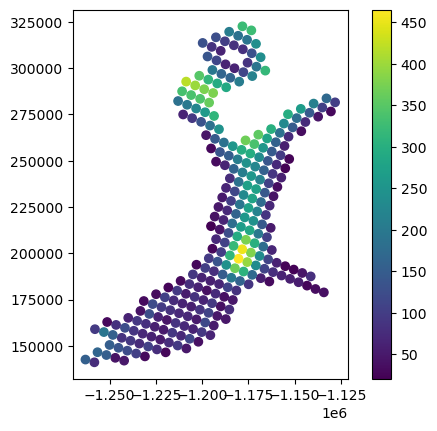

In [45]:
fig, ax = plt.subplots(1,1)
ax.set_aspect(1)
im=plt.scatter(x_cavs, y_cavs, c = geoms.bathymetry.values[idx] - geoms.isf_draft.values[idx])
plt.colorbar(im)

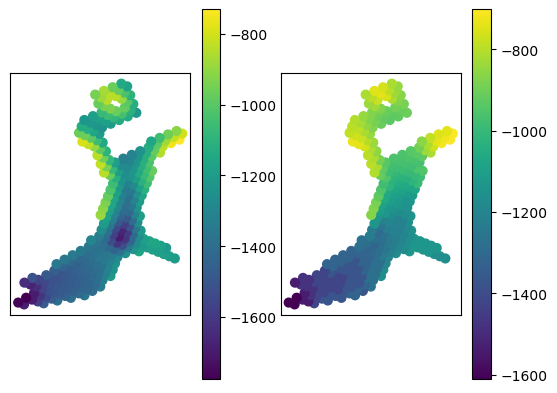

In [42]:
fig, ax = plt.subplots(1,2)
for i in range(2):
    kk = ('bathymetry', 'isf_draft')[i]
    ax[i].set_aspect(1)
    im = ax[i].scatter(x_cavs, y_cavs, c = -geoms[kk].values[idx], s = 40)
    plt.colorbar(im, ax = ax[i])
    ax[i].set_xticks([]); ax[i].set_yticks([]);
    #im.set_clim(750,1700)
#list(geoms.data_vars)

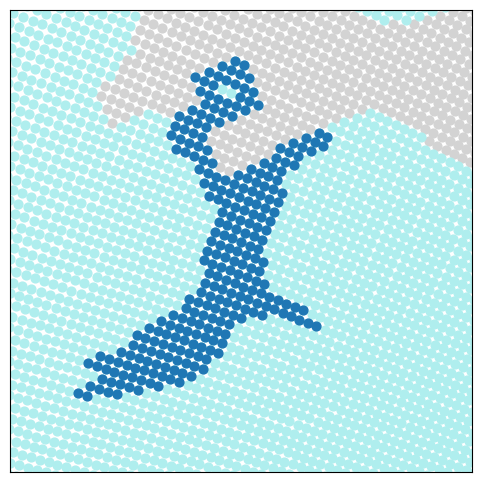

In [20]:
fig, ax = plt.subplots(1,1,figsize = (6,6))
plt.scatter(x_all_cavs, y_all_cavs, c = 'lightgrey', s = 40)
plt.scatter(x_gi, y_gi, c = 'paleturquoise', s = 40)

plt.scatter(x_cavs, y_cavs, s = 40)

plt.xlim(-1.3e6,-1.05e6)
plt.ylim(0.1e6,0.35e6)
#plt.xlim(-1.8e6,-1.4e6)
#plt.ylim(-0.5e6,-0.1e6)
ax.set_aspect(1)
ax.set_xticks([]); ax.set_yticks([]);

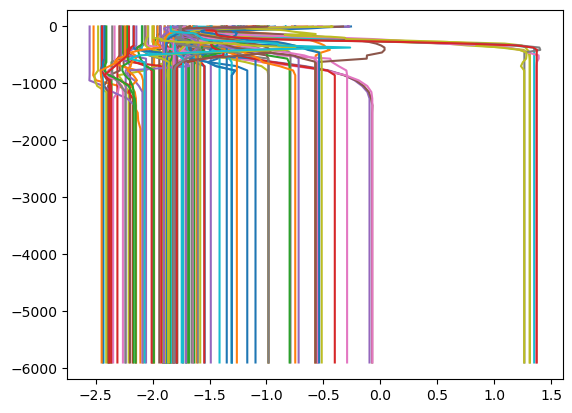

In [18]:
for i in all_profiles.kk:
    plt.plot(all_profiles.isel(kk=i).thetao, -all_profiles.deptht)

In [14]:
all_profiles

<xarray.Dataset> Size: 82kB
Dimensions:  (kk: 134, deptht: 75)
Coordinates:
  * kk       (kk) int64 1kB 0 1 2 3 4 5 6 7 ... 126 127 128 129 130 131 132 133
  * deptht   (deptht) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
Data variables:
    thetao   (kk, deptht) float32 40kB -1.068 -1.083 -1.1 ... -2.364 -2.364
    so       (kk, deptht) float32 40kB 34.15 34.16 34.18 ... 34.75 34.75 34.75
Attributes:
    name:         ECM71-ico-LR-pi-01.pi_1y_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Nov-15 10:20:09 GMT
    uuid:         52a99189-5032-4c03-a468-070ab4a4f919
    LongName:     EIPSLCM7.1-LR
    history:      Wed Nov 19 13:03:11 2025: ncrcat -O -d time_counter,3,3 ECM...
    NCO:          netCDF Operators version 5.0.1 (Homepage = http://nco.sf.ne...

In [ ]:
fig, axs = plt.subplots(1,2, figsize = (6,5))
axs[0].set_position([0,0,1,1])
axs[1].set_position([0.17,0.15,0.3,0.02])
ax = axs[0]
ax.axis('off');
im = ax.scatter(melt.x, melt.y, c = -melt.melt_Gt, s = 0.01, cmap = 'coolwarm')
#print('Maximum melt rate:', -np.min(melt.mean_melt))
im.set_clim(-0.5,0.5)
cbar = plt.colorbar(im, shrink = 0.5, cax = axs[1], orientation = 'horizontal')
cbar.set_label('Melt (Gt/yr)')
ax.annotate('Melting', xy = (0,0), xytext = (0.4, 0.18), xycoords = 'axes fraction', fontsize = 8, color = 'crimson')
ax.annotate('Re-freezing', xy = (0,0), xytext = (0.17, 0.18), xycoords = 'axes fraction', fontsize = 8, color = 'royalblue')
#ax.set_xlim(-2e6,-1e6)
#ax.set_ylim(-1e6,0e6)
for jj in range(len(melt_by_basin.basin)):
    if melt_by_basin.basin[jj] in (49, 105):
       ax.annotate('{}'.format(-int(melt_by_basin.melt_Gt[jj])), xy = (0,0), \
            xytext = (melt_by_basin.x[jj]+1e5, melt_by_basin.y[jj]), xycoords = 'data', \
                fontsize = 6, ha = 'center', va = 'center', color = 'k')    
    else:    
        ax.annotate('{}'.format(-int(melt_by_basin.melt_Gt[jj])), xy = (0,0), \
            xytext = (melt_by_basin.x[jj], melt_by_basin.y[jj]), xycoords = 'data', \
                fontsize = 6, ha = 'center', va = 'center')
ax.annotate('Total melt:\n{:.0f} Gt/yr'.format(-np.nansum((melt_by_basin.melt_Gt))), xy = (0,0), \
            xytext = (0,0), xycoords = 'data', \
                fontsize = 10, ha = 'center', va = 'center');

In [ ]:
# Lets see what the total is from the melt output from TGCC

In [11]:
area_nemo1 = xr.open_dataset(filepath_nemo_output).area.values

In [14]:
### See if input and output are the same 
fp_nn_output = '/bettik/ockendeh/NEMO_simulations/new_limits2/nn_output_melt_1979.nc'
fp_nemo_input = '/bettik/ockendeh/NEMO_simulations/new_limits2/flxT_1980_v2.nc'
nn_output = xr.open_dataset(fp_nn_output)
nemo_input = xr.open_dataset(fp_nemo_input)

In [15]:
np.sum(nemo_input.sowflisf_par.isel(time_counter = 0).fillna(0).values * area_nemo1) * 1e-12 * (60*60*24*365.25), \
np.sum(nn_output.melt * area_nemo1 *1e-12 * (60*60*24*365.25))

(np.float32(2734.491),
 <xarray.DataArray 'melt' ()> Size: 8B
 array(2738.83914966)
 Attributes:
     standard_name:  Sub-shelf melt for parameterised regions
     units:          kg m-2 s-1)

/home/ockendeh/miniconda3/envs/nnets_py38/lib/python3.12/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: divide by zero encountered in log10
  result_data = func(*input_data)
/tmp/ipykernel_143748/272881253.py:4: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


(0.0, 110.0)

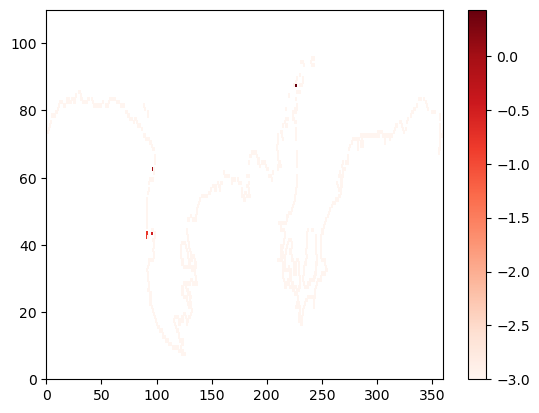

In [16]:
im = plt.pcolor(np.log10(np.abs((nn_output.melt * area_nemo1 * 1e-12 * (60*60*24*365.25)) - (nemo_input.sowflisf_par.isel(time_counter = 0).fillna(0).values) \
                * area_nemo1 * 1e-12 * (60*60*24*365.25))), cmap = 'Reds')
im.set_clim(-3,None)
plt.colorbar()
plt.ylim(0,110)

In [17]:
cells = (nn_output.melt != 0) & (nemo_input.sowflisf_par.isel(time_counter = 0).fillna(0).values == 0)
coords = list(zip(*np.where(cells)))
coords

[(np.int64(42), np.int64(91)),
 (np.int64(43), np.int64(91)),
 (np.int64(43), np.int64(95)),
 (np.int64(62), np.int64(96)),
 (np.int64(87), np.int64(226))]

(0.0, 110.0)

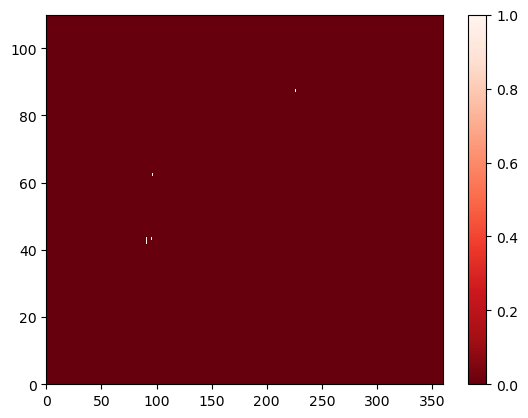

In [20]:
plt.pcolor((nn_output.melt != 0) & (nemo_input.sowflisf_par.isel(time_counter = 0).fillna(0).values == 0), cmap = 'Reds_r')
plt.colorbar()
plt.ylim(0,110)



In [21]:
np.sum((nn_output.melt - nemo_input.sowflisf_par.isel(time_counter = 0).values)*area_nemo1)

<xarray.DataArray 'melt' ()> Size: 8B
array(-0.40461471)
Attributes:
    standard_name:  Sub-shelf melt for parameterised regions
    units:          kg m-2 s-1

/tmp/ipykernel_143748/230346112.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


(0.0, 110.0)

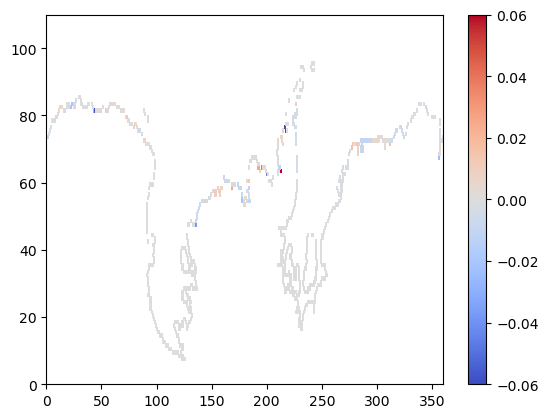

In [22]:
im = plt.pcolor((nn_output.melt - nemo_input.sowflisf_par.isel(time_counter = 0).values)*area_nemo1, \
           cmap = 'coolwarm')
im.set_clim(-0.06,0.06)
#im.set_clim(-0.2e10,0.2e10)
plt.colorbar()
plt.ylim(0,110)

/tmp/ipykernel_143748/3449156958.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


(0.0, 110.0)

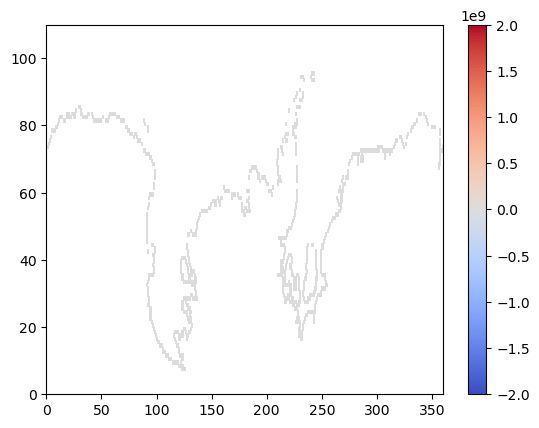

In [23]:
im = plt.pcolor(nn_output.melt - nemo_input.sowflisf_par.isel(time_counter = 0).values, \
           cmap = 'coolwarm')
#im.set_clim(-0.06,0.06)
im.set_clim(-0.2e10,0.2e10)
plt.colorbar()
plt.ylim(0,110)

# To compare multiple years of NEMO output 

In [10]:
area_nemo1 = xr.open_dataset(filepath_nemo_output).area.values

In [11]:
output_melts = []

import glob
filepaths = glob.glob('/bettik/ockendeh/NEMO_simulations/new_limits2/nn_output_melt_TOTO_*.nc')
filepaths = sorted(filepaths)
for i in range(len(filepaths)):
    melt = xr.open_dataset(filepaths[i])
    #print(np.nansum(melt.melt))
    total_melt = melt.melt * area_nemo1 * (60*60*24*365.25)/1e12
    output_melts.append(np.nansum(total_melt))
    print(np.nansum(total_melt))

3088.067674613937
2269.2225592430723
2171.786048348989
2165.960420364627
2102.8549735602587
2045.0856890946798
1980.7728213648904
1952.573546009409
1825.271351991112
1825.824737664936


In [12]:
input_melts = []
cav_melts = []

filepaths2 = glob.glob('/bettik/ockendeh/NEMO_simulations/new_limits2/eORCA1.L75-TOTO_1y_flxT*.nc')
filepaths2 = sorted(filepaths2)
for i in range(len(filepaths2)):
    if i > 0:
        fluxes = xr.open_dataset(filepaths2[i])
        innemo = np.nansum(fluxes.sowflisf_par.isel(time_counter = 0) * fluxes.area * (60*60*24*365.25) / 1e12)
        input_melts.append(innemo)
        print(innemo)
        incavs = np.nansum(fluxes.sowflisf_cav.isel(time_counter = 0) * fluxes.area * (60*60*24*365.25)/1e12)
        cav_melts.append(incavs)
        #print(incavs)

3088.0676
2269.2227
2171.7861
2165.9604
2102.8552
2045.0858
1980.7728
1952.5736
1825.2714


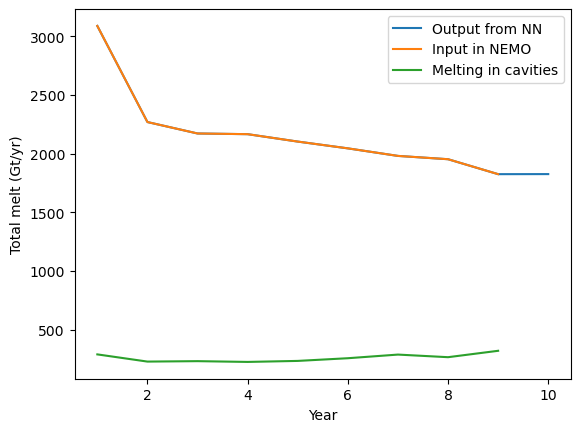

In [13]:
fig, ax = plt.subplots(1,1)
plt.plot(np.arange(1,11,1),output_melts, label = 'Output from NN')
plt.plot(np.arange(1,10,1),input_melts, label = 'Input in NEMO')
plt.plot(np.arange(1,10,1), cav_melts, label = 'Melting in cavities')
plt.xlabel('Year')
plt.ylabel('Total melt (Gt/yr)')
plt.legend()

In [14]:
# To compare to another run

In [18]:
def calculate_total(filepath_star, variable):
    filepaths = glob.glob(filepath_star)
    filepaths = sorted(filepaths)
    years = np.ndarray(len(filepaths)-1)
    variable_by_year = np.ndarray(len(filepaths)-1)
    for i in range(len(filepaths)):
        if i > 0:
            years[i-1] = int(filepaths[i].split('flxT_')[1].split('-')[0])
            flx = xr.open_dataset(filepaths[i])
            #print(np.nansum(melt.melt))
            total_melt = np.nansum(flx[variable].isel(time_counter = 0) * area_nemo1 * (60*60*24*365.25)/1e12)
            variable_by_year[i-1] = total_melt
            flx.close()
        print(i, 'out of', len(filepaths), end = '\r')
    return years, variable_by_year 

In [19]:
years, melt_par = calculate_total('/bettik/ockendeh/NEMO_simulations/new_limits/eORCA1.L75-TOTO_1y_flxT*.nc', 'sowflisf_par')
years, melt_cav = calculate_total('/bettik/ockendeh/NEMO_simulations/new_limits/eORCA1.L75-TOTO_1y_flxT*.nc', 'sowflisf_cav')

In [20]:
years2, melt_par2 = calculate_total('/bettik/ockendeh/NEMO_simulations/perfect_BM3/eORCA1.L75-TOTO_1y_flxT*.nc', 'sowflisf_par')
years2, melt_cav2 = calculate_total('/bettik/ockendeh/NEMO_simulations/perfect_BM3/eORCA1.L75-TOTO_1y_flxT*.nc', 'sowflisf_cav')

In [21]:
melt_par2+ melt_cav2

array([1974.98498535, 1414.04898071, 1398.33554077, 1392.67108154,
       1364.80859375, 1376.76763916, 1383.22787476, 1397.87759399,
       1382.11288452, 1362.66104126, 1344.96151733, 1348.96994019,
       1375.25119019, 1298.00027466, 1243.02276611, 1203.5055542 ,
       1220.71655273, 1223.64407349, 1293.89611816, 1265.32608032,
       1196.0189209 , 1215.44946289, 1312.71893311, 1374.2947998 ,
       1370.05325317, 1388.04663086, 1416.94555664, 1383.31130981,
       1355.14172363, 1332.19729614, 1392.47924805, 1395.38775635,
       1378.01446533, 1352.18276978, 1345.12176514, 1227.99188232,
       1308.39862061, 1395.91168213, 1387.83404541])

In [22]:
#filepaths = glob.glob('/bettik/ockendeh/NEMO_simulations/files_bmach2/nn_output_melt_*.nc')
#filepaths = sorted(filepaths)
#sums = []
#for i in range(len(filepaths)):
#    test_melt = xr.open_dataset(filepaths[i])
#    tester_sum = np.sum(test_melt.melt*area_nemo1 * (60*60*24*365.25)/1e12)
#    sums.append(tester_sum)

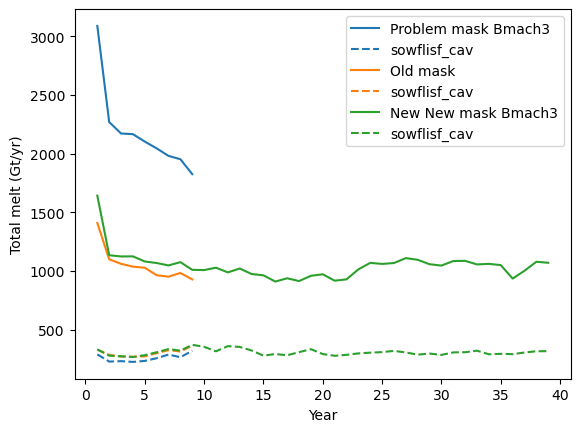

In [23]:
fig, ax = plt.subplots(1,1)
plt.plot(np.arange(1,10,1),output_melts[:-1], label = 'Problem mask Bmach3')
plt.plot(np.arange(1,10,1), cav_melts, label = 'sowflisf_cav', c = 'C0', linestyle = '--')
plt.plot(years-1979, melt_par, label = 'Old mask ')
plt.plot(years-1979, melt_cav, label = 'sowflisf_cav', c = 'C1', linestyle = '--')
plt.plot(years2-1979, melt_par2, label = 'New New mask Bmach3')
plt.plot(years2-1979, melt_cav2, label = 'sowflisf_cav', c = 'C2', linestyle = '--')
plt.xlabel('Year')
plt.ylabel('Total melt (Gt/yr)')
plt.legend();

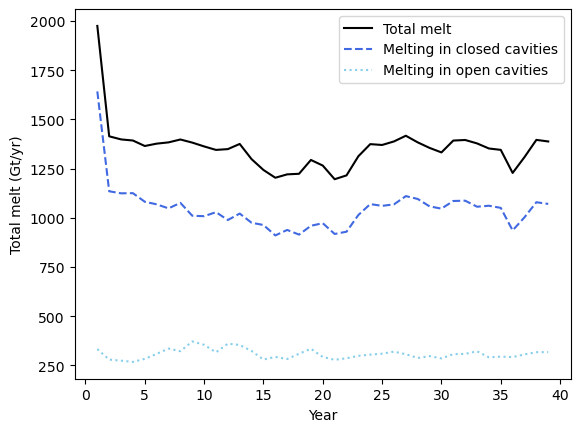

In [32]:
fig, ax = plt.subplots(1,1)
plt.plot(years2-1979, melt_par2 + melt_cav2, label = 'Total melt',  c = 'k', linestyle = '-')
plt.plot(years2-1979, melt_par2, label = 'Melting in closed cavities', c = 'royalblue', linestyle = '--')
plt.plot(years2-1979, melt_cav2, label = 'Melting in open cavities', c = 'skyblue', linestyle = ':')
plt.xlabel('Year')
plt.ylabel('Total melt (Gt/yr)')
plt.legend();

In [33]:
filepath_OPM026 = '../AIAI_data/Training_data/OPM026_whole_dataset_not_yet_normalised.csv'

In [37]:
OPM026 = pd.read_csv(filepath_OPM026)

In [54]:
OPM026['melt_Gt_per_y'] = OPM026.melt_m_ice_per_y * OPM026.area * (60*60*24*365.25)/(1e12)/12

In [55]:
OPM026_year = OPM026.groupby('year', as_index = False).sum()

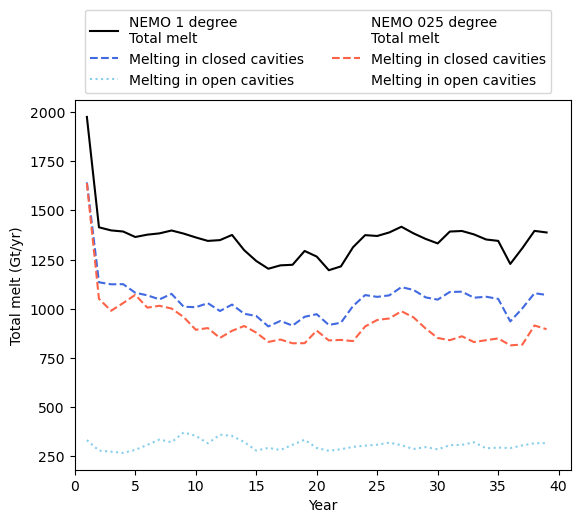

In [76]:
fig, ax = plt.subplots(1,1)
plt.plot(years2-1979, melt_par2 + melt_cav2, label = 'NEMO 1 degree\nTotal melt',  c = 'k', linestyle = '-')
plt.plot(years2-1979, melt_par2, label = 'Melting in closed cavities', c = 'royalblue', linestyle = '--')
plt.plot(years2-1979, melt_cav2, label = 'Melting in open cavities', c = 'skyblue', linestyle = ':')

plt.scatter((-1,-1), (500,500), label = 'NEMO 025 degree\nTotal melt', c = 'white')
plt.plot(OPM026_year.year[0:39]-1978, -OPM026_year.melt_Gt_per_y[0:39], label = 'Melting in closed cavities', 
         c = 'tomato', linestyle = '--')
plt.scatter((-1,-1), (500,500), label = 'Melting in open cavities', c = 'white')
plt.xlim(0, None)

plt.xlabel('Year')
plt.ylabel('Total melt (Gt/yr)')
plt.legend(ncols = 2, loc = (0.02,1.02));

fig.savefig('FIGURES/Compare_1and025.jpg', dpi = 200, bbox_inches = 'tight')